# Swiss Statistics Data Explorer

Interactive exploration of hectare-level datasets (STATPOP, BDS, SLS, STATENT)
aggregated to municipality level via `swiss_stats` module.

In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from rasterio.transform import from_origin

import numpy as np
import sys
from pathlib import Path

# Ensure swiss_stats is importable
module_parent = Path(".").resolve().parent 
if str(module_parent) not in sys.path:
    sys.path.insert(0, str(module_parent))

import swiss_stats
from swiss_stats.variable_catalog import get_selected_columns, DATASET_CATALOGS
from swiss_stats.loaders import load_dataset
from swiss_stats.aggregate import aggregate_to_municipalities, aggregate_dataset
from swiss_stats.cache import save_cache, load_cache, is_cache_valid
from swiss_stats import SLS_CLASS_LABELS


## 1. Inspect Variable Catalogs

See how many variables are selected per dataset.

In [2]:
for key in DATASET_CATALOGS:
    cols = get_selected_columns(key)
    print(f"{key.upper():10s}: {len(cols)} variables")
    # Show first 5
    for code in cols[:5]:
        print(f"  {code:15s} → {DATASET_CATALOGS[key][code]}")
    if len(cols) > 5:
        print(f"  ... and {len(cols) - 5} more")
    print()

STATPOP   : 77 variables
  BBTOT           → Permanent resident population, total
  BB11            → Swiss nationals
  BB12            → Foreign nationals, total
  BB13            → EU/EFTA nationals
  BB14            → Other European nationals
  ... and 72 more

BDS       : 213 variables
  GTOT            → Residential buildings, total
  GTF             → Total footprint area of residential buildings (m²)
  GA01            → Residential buildings, total (all types)
  GA02            → Purely residential buildings
  GA03            → Single-family houses
  ... and 208 more

SLS       : 49 variables
  FJ85            → Exact survey year, period 1979/85
  FJ97            → Exact survey year, period 1992/97
  FJ09            → Exact survey year, period 2004/09
  FJ18            → Exact survey year, period 2013/18
  FJ25            → Exact survey year, period 2018/25
  ... and 44 more

STATENT   : 307 variables
  B08T            → Establishments, total
  B08S1           → Establishments, 

## 2. Load a Dataset

Load STATPOP with a small subset of columns to test.

In [14]:
# Load a small subset for quick testing
test_cols = ["GB01", "GB02"]
ldf = load_dataset("bds", columns=test_cols)
ldf.head()

ValueError: Usecols do not match columns, columns expected but not found: ['E_KOORD', 'GB02', 'GB01', 'RELI', 'N_KOORD']

In [12]:
# Load a small subset for quick testing
test_cols = ["BBTOT", "BBMTOT", "BBWTOT", "HPTOT"]
ldf = load_dataset("statpop", columns=test_cols)
ldf.head()

,E_KOORD,N_KOORD,BBTOT,BBMTOT,BBWTOT,HPTOT
RELI,,,,,,
48621114,2486200,1111400,5,0,5,3
48621115,2486200,1111500,3,3,0,3
48631114,2486300,1111400,4,3,3,3
48631117,2486300,1111700,3,3,3,3
48641116,2486400,1111600,30,15,15,11


In [40]:
# Load a small subset for quick testing
ldf_c = load_dataset("sls", )
ldf_c.head()

,E_COORD,N_COORD,FJ85,FJ97,FJ09,FJ18,FJ25,AS85_17,AS97_17,AS09_17,...,LU85_10,LU97_10,LU09_10,LU18_10,LU25_10,LU85_4,LU97_4,LU09_4,LU18_4,LU25_4
RELI,,,,,,,,,,,,,,,,,,,,,
48551097,2485500,1109700,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551098,2485500,1109800,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551099,2485500,1109900,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551100,2485500,1110000,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551101,2485500,1110100,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0


In [27]:
import swisslandstats as sls
ldf = sls.load_dataset(dataset_key="sls")

In [42]:
ldf_c

,E_COORD,N_COORD,FJ85,FJ97,FJ09,FJ18,FJ25,AS85_17,AS97_17,AS09_17,...,LU85_10,LU97_10,LU09_10,LU18_10,LU25_10,LU85_4,LU97_4,LU09_4,LU18_4,LU25_4
RELI,,,,,,,,,,,,,,,,,,,,,
48551097,2485500,1109700,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551098,2485500,1109800,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551099,2485500,1109900,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551100,2485500,1110000,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
48551101,2485500,1110100,1980,1992,2004,2012,2020.0,10,10,10,...,300,300,300,300,300.0,3,3,3,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83381668,2833800,1166800,1985,1997,2009,2019,NaN,16,16,16,...,420,420,420,420,NaN,4,4,4,4,NaN
83381669,2833800,1166900,1985,1997,2009,2019,NaN,16,16,16,...,420,420,420,420,NaN,4,4,4,4,NaN
83381670,2833800,1167000,1985,1997,2009,2019,NaN,15,15,15,...,420,420,420,420,NaN,4,4,4,4,NaN


In [ ]:
ldf.columns

Index(['E_COORD', 'N_COORD', 'FJ85', 'FJ97', 'FJ09', 'FJ18', 'FJ25', 'LC85_27',
       'LC97_27', 'LC09_27', 'LC18_27', 'LC25_27', 'LC85_6', 'LC97_6',
       'LC09_6', 'LC18_6', 'LC25_6', 'LU85_46', 'LU97_46', 'LU09_46',
       'LU18_46', 'LU25_46', 'LU85_10', 'LU97_10', 'LU09_10', 'LU18_10',
       'LU25_10', 'LU85_4', 'LU97_4', 'LU09_4', 'LU18_4', 'LU25_4'],
      dtype='object')

<Axes: >

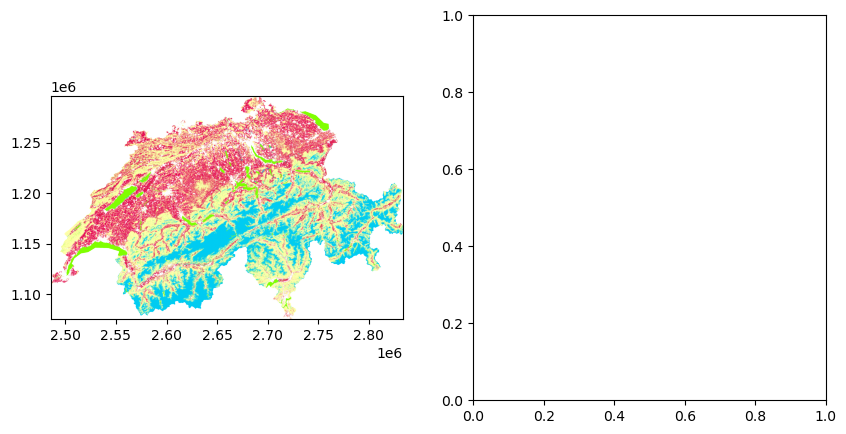

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ldf_c.plot("AS18_17", cmap=sls.noas04_4_cmap, ax=axes[0])


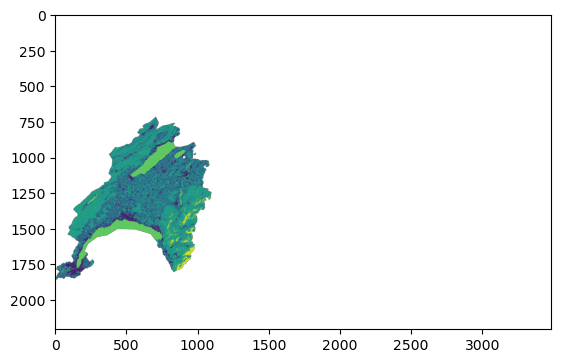

In [25]:
col = "AS25_17"
arr_df = ldf[['E_COORD', 'N_COORD', col]].reset_index(drop=True)
grid = arr_df.pivot(index="N_COORD", columns="E_COORD", values=col).sort_index(ascending=False)

geo_arr = grid.to_numpy()
transform = from_origin(grid.columns.min() - 50, grid.index.max() + 50, 100, 100)
crs = "EPSG:2056"
plt.imshow(geo_arr)

In [9]:
# Load a small subset for quick testing
test_cols = ["B0802EMP","B0803VZA"]
ldf = load_dataset("statent", columns=test_cols)
ldf.head()

ValueError: Usecols do not match columns, columns expected but not found: ['E_KOORD', 'B0803VZA', 'B0802EMP', 'RELI', 'N_KOORD']

## 3. Aggregate to Municipalities

Spatial join + group by BFS_NUMMER.

In [5]:
result = aggregate_to_municipalities(ldf, test_cols)
print(f"Municipalities: {len(result)}")
# result.sort_values("BBTOT", ascending=False).head(10)

Municipalities: 2123


In [12]:
ldf['AS25_17'].fillna(0).value_counts()

AS25_17
0.0     3532153
10.0     168792
7.0      113651
8.0       89120
13.0      59992
9.0       54544
2.0       34848
3.0       19950
12.0      13805
6.0        9922
15.0       9487
16.0       6040
5.0        4591
1.0        4377
4.0        3207
14.0       2638
11.0       1688
17.0        266
Name: count, dtype: int64

In [13]:
result.sort_values("AS25_17", ascending=False).head(10)

,NAME,AS25_17,LU25_10
BFS_NUMMER,,,
5402,Bex,17.0,420.0
5411,Ormont-Dessus,17.0,420.0
5764,Vallorbe,16.0,420.0
5405,Gryon,16.0,420.0
5407,Leysin,16.0,420.0
5408,Noville,16.0,420.0
5409,Ollon,16.0,420.0
5410,Ormont-Dessous,16.0,420.0
5886,Montreux,16.0,420.0


## 4. Sanity Check

Compare known city populations against aggregated values.

In [9]:
# Known approximate populations (2022):
# Zürich (BFS 261) ~440k, Bern (BFS 351) ~134k, Basel (BFS 2701) ~178k
known = {261: "Zürich", 351: "Bern", 2701: "Basel"}
for bfs, name in known.items():
    if bfs in result.index:
        pop = result.loc[bfs, "BBTOT"]
        print(f"{name} (BFS {bfs}): {pop:,.0f}")
    else:
        print(f"{name} (BFS {bfs}): not found")

KeyError: 'BBTOT'

## 5. Cache Round-Trip

Save to parquet and read back.

In [6]:
save_cache("statpop", result)
cached = load_cache("statpop")
print(f"Cache valid: {is_cache_valid('statpop')}")
print(f"Round-trip OK: {result.equals(cached)}")

Cache valid: True
Round-trip OK: True


## 6. Full Pipeline (all datasets)

Uncomment to run the full pipeline for all four datasets.
Warning: first download of SLS is ~700MB.

In [7]:
# Uncomment to run:
# from swiss_stats.run import main
# main()